# align_ref_timing

For patients where the Praat ref timestamps are misaligned with WhisperX hyp timestamps
(different audio start reference), this notebook:

1. Finds matched sentence pairs using WER-only matching (no timing constraint)
2. Estimates a linear timing correction: `hyp_time ≈ a * ref_time + b`
3. Applies the correction and saves `word_info_timing_corrected.csv`

`convo_accuracy_evaluation.ipynb` automatically prefers this corrected CSV when it exists,
so corrected patients are handled identically to aligned ones.

**Known misaligned patients:** YFA (ref 1–2459 s, hyp 1085–3554 s, ~+1083 s offset),
YEZ (small offset, included as a precaution).

In [2]:
import bisect
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz.distance import Levenshtein
from rapidfuzz.fuzz import token_set_ratio

In [3]:
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path("/mnt/labworlds/Hayden/Hayden_Lab/speech_247")
ANILU_ROOT = DATA_ROOT / "anilu_comparison"

# Patients to correct.  Run on any patient you suspect is misaligned.
PATIENTS_TO_CORRECT = ["YFA", "YEZ"]

# Output filename (saved alongside word_info.csv, never overwrites it)
OUT_FILENAME = "word_info_timing_corrected.csv"

# WER matching params for finding timing anchors.
# Use stricter thresholds than the evaluation notebook — we want clean anchor pairs.
ANCHOR_WER_THRESH   = 0.70   # min WER similarity to accept as anchor
ANCHOR_CHEAP_THRESH = 60     # token_set_ratio pre-filter
ANCHOR_MIN_TOKENS   = 5      # only use longer sentences as anchors
ANCHOR_SIZE_SLACK   = 5      # hyp window size ± ref length
ANCHOR_SAMPLE_EVERY = 15     # sample every Nth ref sentence (speeds up global search)

## Utility functions

Self-contained copy of the WER / alignment utilities from `convo_accuracy_evaluation.ipynb`.

In [4]:
_word_re = re.compile(r"[^\w']+", re.UNICODE)


def norm_word(w: str) -> str:
    return _word_re.sub("", w.lower().strip()) if w else ""


def norm_tokens(words: list[str]) -> list[str]:
    return [t for w in words if (t := norm_word(str(w)))]


def join_tokens(tokens: list[str]) -> str:
    return " ".join(tokens)


FILLER_TOKENS: frozenset[str] = frozenset({
    "x",
    "haha", "hahaha", "hah", "ha",
    "um", "umm", "uh", "uhh", "uhm",
    "mmhmm", "mhm", "uhhuh",
})


def is_match(a: str, b: str) -> bool:
    if not a or not b:
        return False
    if a == b:
        return True
    dist = Levenshtein.distance(a, b)
    return dist <= (1 if min(len(a), len(b)) <= 4 else 2)


from dataclasses import dataclass

@dataclass
class AlignResult:
    pairs: list
    S: int
    D: int
    I: int
    N: int


def align_tokens(ref: list[str], hyp: list[str], match_fn=is_match) -> AlignResult:
    n, m = len(ref), len(hyp)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    bt = [[None] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        dp[i][0], bt[i][0] = i, "D"
    for j in range(1, m + 1):
        dp[0][j], bt[0][j] = j, "I"
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            sub = 0 if match_fn(ref[i - 1], hyp[j - 1]) else 1
            cands = [
                (dp[i-1][j-1] + sub, "M" if sub == 0 else "S"),
                (dp[i-1][j] + 1,     "D"),
                (dp[i][j-1] + 1,     "I"),
            ]
            dp[i][j], bt[i][j] = min(cands, key=lambda x: x[0])
    i, j = n, m
    pairs, S, D, I = [], 0, 0, 0
    while i > 0 or j > 0:
        step = bt[i][j]
        if step in ("M", "S"):
            if step == "S": S += 1
            pairs.append((i - 1, j - 1, step == "M"))
            i -= 1; j -= 1
        elif step == "D":
            D += 1; pairs.append((i - 1, None, False)); i -= 1
        elif step == "I":
            I += 1; pairs.append((None, j - 1, False)); j -= 1
        else:
            break
    pairs.reverse()
    return AlignResult(pairs=pairs, S=S, D=D, I=I, N=n)


def wer_similarity(aln: AlignResult) -> float:
    if aln.N == 0:
        return float("nan")
    return max(0.0, 1.0 - (aln.S + aln.D + aln.I) / aln.N)


def build_content_mask(tokens: list[str]) -> list[int]:
    mask, last = [], None
    for i, t in enumerate(tokens):
        if t in FILLER_TOKENS: continue
        if t == last: continue
        mask.append(i); last = t
    return mask

## Load ref and hyp data

In [5]:
def load_ref(pt: str) -> pd.DataFrame:
    word_csv = ANILU_ROOT / pt / "words" / "word_info.csv"
    df = pd.read_csv(word_csv, index_col=0)
    df = df.sort_values("onset").reset_index(drop=True)
    df["word_start_s"] = df["onset"]  / 1_000.0
    df["word_end_s"]   = df["offset"] / 1_000.0

    # Build sentence_id from terminal punctuation
    sentence_id, ids = 0, []
    for word in df["CollapsedWord"]:
        ids.append(sentence_id)
        if any(c in {"?", "!", "."} for c in str(word)):
            sentence_id += 1
    df["sentence_id"] = ids
    return df


def load_hyp(pt: str) -> pd.DataFrame:
    hyp_csv = ANILU_ROOT / pt / "whisperx_out" / "audio_transcript_df.csv"
    df = pd.read_csv(hyp_csv, index_col=0)
    df = df.rename(columns={
        "start_ts":      "word_start_s",
        "end_ts":        "word_end_s",
        "qscore":        "word_score",
        "segment_start": "segment_start_s",
        "segment_end":   "segment_end_s",
    })
    return df.sort_values("word_start_s").reset_index(drop=True)


def build_ref_sentences(ref_df: pd.DataFrame) -> list[dict]:
    sents = []
    for sent_id, g in ref_df.groupby("sentence_id", sort=True):
        g = g.sort_values("word_start_s").reset_index(drop=True)
        tokens = norm_tokens(g["CollapsedWord"].tolist())
        content_mask = build_content_mask(tokens)
        content_toks = [tokens[i] for i in content_mask]
        sents.append({
            "sent_id":        sent_id,
            "ref_df":         g,
            "ref_tokens":     tokens,
            "ref_text":       join_tokens(tokens),
            "content_tokens": content_toks,
            "ref_lo":  float(g["word_start_s"].min()),
            "ref_hi":  float(g["word_end_s"].max()),
            "ref_mid": (float(g["word_start_s"].min()) + float(g["word_end_s"].max())) / 2.0,
        })
    return sents


# Load all misaligned patients
pt_refs:  dict[str, pd.DataFrame] = {}
pt_hyps:  dict[str, pd.DataFrame] = {}
pt_sents: dict[str, list]         = {}

for pt in PATIENTS_TO_CORRECT:
    pt_refs[pt]  = load_ref(pt)
    pt_hyps[pt]  = load_hyp(pt)
    pt_sents[pt] = build_ref_sentences(pt_refs[pt])

    ref = pt_refs[pt]
    hyp = pt_hyps[pt]
    print(f"{pt}:")
    print(f"  ref {len(ref)} words, {ref['word_start_s'].min():.1f}–{ref['word_start_s'].max():.1f} s")
    print(f"  hyp {len(hyp)} words, {hyp['word_start_s'].min():.1f}–{hyp['word_start_s'].max():.1f} s")
    print(f"  apparent offset: ~{hyp['word_start_s'].median() - ref['word_start_s'].median():.1f} s")

YFA:
  ref 8260 words, 1.6–2459.3 s
  hyp 6900 words, 1085.4–3553.9 s
  apparent offset: ~1083.0 s
YEZ:
  ref 5279 words, 324.0–2653.4 s
  hyp 4915 words, 316.6–2651.8 s
  apparent offset: ~71.0 s


## Find timing anchor pairs via global WER matching

For a sparse sample of ref sentences we search the **entire** hyp (no timing constraint)
for the best WER match.  Only high-confidence pairs (WER-sim ≥ 0.70) are kept as anchors
for the subsequent regression step.

In [6]:
def find_timing_anchors(
    ref_sents:    list[dict],
    hyp_df:       pd.DataFrame,
    wer_thresh:   float = ANCHOR_WER_THRESH,
    cheap_thresh: float = ANCHOR_CHEAP_THRESH,
    min_tokens:   int   = ANCHOR_MIN_TOKENS,
    size_slack:   int   = ANCHOR_SIZE_SLACK,
    sample_every: int   = ANCHOR_SAMPLE_EVERY,
) -> pd.DataFrame:
    """
    Sample every `sample_every`-th ref sentence, do a global hyp search for the
    best WER match, and return a DataFrame of (ref_mid, hyp_mid, wer_sim) anchor pairs.
    """
    hyp_sorted = hyp_df.sort_values("word_start_s").reset_index(drop=True)

    norm_entries: list[tuple[str, int, float]] = []
    for i, row in hyp_sorted.iterrows():
        t = norm_word(str(row["word"]))
        if t:
            norm_entries.append((t, int(i), float(row["word_start_s"])))

    hyp_norm  = [e[0] for e in norm_entries]
    hyp_times = [e[2] for e in norm_entries]

    anchors = []
    sampled_indices = [
        i for i, rs in enumerate(ref_sents)
        if i % sample_every == 0
        and len(rs["content_tokens"]) >= min_tokens
    ]
    print(f"  Searching {len(sampled_indices)} sampled ref sentences against {len(hyp_norm)} hyp words…")

    for count, i in enumerate(sampled_indices):
        rs = ref_sents[i]
        ref_tokens = rs["ref_tokens"]
        n          = len(ref_tokens)
        ref_text   = rs["ref_text"]
        ref_mid    = rs["ref_mid"]

        best_wer     = -1.0
        best_hyp_mid = None
        best_hyp_text = None

        w_min = max(1, n - size_slack)
        w_max = n + size_slack

        for start in range(0, len(hyp_norm)):
            for w_size in range(w_min, w_max + 1):
                end = start + w_size
                if end > len(hyp_norm):
                    break

                window   = hyp_norm[start:end]
                hyp_text = join_tokens(window)

                cs = float(token_set_ratio(ref_text, hyp_text))
                if cs < cheap_thresh:
                    continue

                aln = align_tokens(ref_tokens, window)
                ws  = wer_similarity(aln)

                if ws >= wer_thresh and ws > best_wer:
                    best_wer      = ws
                    best_hyp_mid  = (hyp_times[start] + hyp_times[end - 1]) / 2.0
                    best_hyp_text = hyp_text

        if best_hyp_mid is not None:
            anchors.append({
                "ref_mid":  ref_mid,
                "hyp_mid":  best_hyp_mid,
                "wer_sim":  best_wer,
                "ref_text": ref_text,
                "hyp_text": best_hyp_text,
            })

        if (count + 1) % 10 == 0:
            print(f"    … {count + 1}/{len(sampled_indices)} done, {len(anchors)} anchors so far")

    print(f"  Found {len(anchors)} anchor pairs")
    return pd.DataFrame(anchors)

In [7]:
pt_anchors: dict[str, pd.DataFrame] = {}

for pt in PATIENTS_TO_CORRECT:
    print(f"\n{pt}:")
    anchors = find_timing_anchors(pt_sents[pt], pt_hyps[pt])
    pt_anchors[pt] = anchors

    if len(anchors) > 0:
        shifts = anchors["hyp_mid"] - anchors["ref_mid"]
        print(f"  Raw shift — median: {shifts.median():.2f} s, "
              f"mean: {shifts.mean():.2f} s, std: {shifts.std():.2f} s")
        print(anchors[["ref_mid", "hyp_mid", "wer_sim", "ref_text", "hyp_text"]].head(8).to_string())


YFA:
  Searching 52 sampled ref sentences against 6900 hyp words…
    … 10/52 done, 7 anchors so far
    … 20/52 done, 14 anchors so far
    … 30/52 done, 21 anchors so far
    … 40/52 done, 27 anchors so far
    … 50/52 done, 31 anchors so far
  Found 31 anchor pairs
  Raw shift — median: 1094.96 s, mean: 1094.23 s, std: 2.96 s
      ref_mid    hyp_mid   wer_sim                                                                                                                 ref_text                                                                                                                hyp_text
0   69.824000  1164.8780  0.956522  yeah exactly that's the goal so basically he has a a bunch of different electrodes in his head right and so whenever he   yeah exactly that's the goal so basically he has a bunch of different electrodes in his head right and so whenever he
1  121.115140  1216.0725  0.789474               there's a bunch of i'm sure they've probably talked to you there's 

## Estimate timing correction via linear regression

Fits `hyp_time = a * ref_time + b` across the anchor pairs.  
If `a` is very close to 1 the relationship is a pure constant offset; otherwise there is
both a time-base difference and an offset (e.g. different recording clocks).

In [8]:
def estimate_correction(anchors: pd.DataFrame) -> tuple[float, float]:
    """
    Fit hyp_mid = a * ref_mid + b and return (a, b).
    Uses median absolute deviation to remove outlier anchor pairs first.
    """
    if len(anchors) < 3:
        raise ValueError(f"Too few anchor pairs ({len(anchors)}) — cannot estimate correction")

    # Remove outliers: keep anchors whose shift is within 3 * MAD of the median
    shifts  = (anchors["hyp_mid"] - anchors["ref_mid"]).values
    med     = float(np.median(shifts))
    mad     = float(np.median(np.abs(shifts - med)))
    inliers = np.abs(shifts - med) <= max(3 * mad, 10.0)   # min 10 s tolerance
    clean   = anchors[inliers].reset_index(drop=True)
    print(f"  Inliers after MAD filter: {inliers.sum()}/{len(anchors)}")

    # Linear fit on inliers
    a, b = np.polyfit(clean["ref_mid"].values, clean["hyp_mid"].values, 1)
    print(f"  Linear fit: hyp_time = {a:.6f} * ref_time + {b:.3f} s")
    if abs(a - 1.0) < 0.002:
        print(f"  Slope ≈ 1 → treating as pure constant offset: {b:.3f} s")
    else:
        print(f"  WARNING: slope {a:.6f} deviates from 1 — both scaling and offset applied")
    return float(a), float(b)


pt_corrections: dict[str, tuple[float, float]] = {}

for pt in PATIENTS_TO_CORRECT:
    print(f"\n{pt}:")
    a, b = estimate_correction(pt_anchors[pt])
    pt_corrections[pt] = (a, b)


YFA:
  Inliers after MAD filter: 29/31
  Linear fit: hyp_time = 1.000012 * ref_time + 1094.982 s
  Slope ≈ 1 → treating as pure constant offset: 1094.982 s

YEZ:
  Inliers after MAD filter: 19/19
  Linear fit: hyp_time = 0.999841 * ref_time + -0.426 s
  Slope ≈ 1 → treating as pure constant offset: -0.426 s


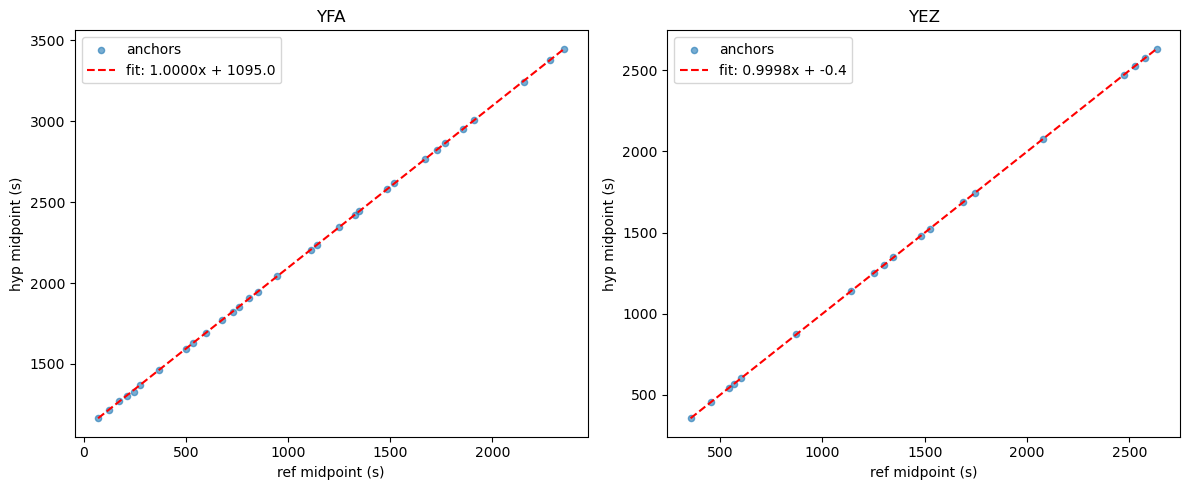

In [9]:
# Visual check: anchor scatter + fitted line
fig, axes = plt.subplots(1, len(PATIENTS_TO_CORRECT), figsize=(6 * len(PATIENTS_TO_CORRECT), 5))
if len(PATIENTS_TO_CORRECT) == 1:
    axes = [axes]

for ax, pt in zip(axes, PATIENTS_TO_CORRECT):
    anchors = pt_anchors[pt]
    a, b    = pt_corrections[pt]

    ax.scatter(anchors["ref_mid"], anchors["hyp_mid"], s=20, alpha=0.6, label="anchors")
    x_line = np.linspace(anchors["ref_mid"].min(), anchors["ref_mid"].max(), 200)
    ax.plot(x_line, a * x_line + b, "r--", lw=1.5, label=f"fit: {a:.4f}x + {b:.1f}")
    ax.set_xlabel("ref midpoint (s)")
    ax.set_ylabel("hyp midpoint (s)")
    ax.set_title(pt)
    ax.legend()

plt.tight_layout()
plt.show()

## Apply correction and save `word_info_timing_corrected.csv`

In [10]:
def apply_correction_and_save(pt: str, a: float, b: float) -> Path:
    """
    Apply corrected_time = a * original_time + b to onset/offset,
    then save word_info_timing_corrected.csv alongside word_info.csv.
    """
    ref = pt_refs[pt].copy()

    # Apply correction in the original millisecond columns so all downstream
    # code that reads onset/offset still gets correct values.
    ref["onset"]  = a * ref["onset"]  + b * 1_000.0
    ref["offset"] = a * ref["offset"] + b * 1_000.0

    # Re-derive word_start_s / word_end_s
    ref["word_start_s"] = ref["onset"]  / 1_000.0
    ref["word_end_s"]   = ref["offset"] / 1_000.0

    out_path = ANILU_ROOT / pt / "words" / OUT_FILENAME
    ref.to_csv(out_path)
    return out_path


for pt in PATIENTS_TO_CORRECT:
    a, b = pt_corrections[pt]
    out_path = apply_correction_and_save(pt, a, b)

    # Quick sanity: check corrected first-word time vs hyp first-word time
    corrected  = pd.read_csv(out_path, index_col=0)
    hyp        = pt_hyps[pt]
    print(f"{pt}: saved → {out_path}")
    print(f"  corrected onset range: {corrected['word_start_s'].min():.1f}–{corrected['word_start_s'].max():.1f} s")
    print(f"  hyp range:             {hyp['word_start_s'].min():.1f}–{hyp['word_start_s'].max():.1f} s")

YFA: saved → /mnt/labworlds/Hayden/Hayden_Lab/speech_247/anilu_comparison/YFA/words/word_info_timing_corrected.csv
  corrected onset range: 1096.6–3554.3 s
  hyp range:             1085.4–3553.9 s
YEZ: saved → /mnt/labworlds/Hayden/Hayden_Lab/speech_247/anilu_comparison/YEZ/words/word_info_timing_corrected.csv
  corrected onset range: 323.5–2652.6 s
  hyp range:             316.6–2651.8 s


## Validation: residual shift distribution after correction

Re-run anchor matching on the **corrected** ref to confirm residuals are small (< 5 s).


YFA — validating corrected timing with a smaller sample:
  Searching 47 sampled ref sentences against 6900 hyp words…
    … 10/47 done, 6 anchors so far
    … 20/47 done, 10 anchors so far
    … 30/47 done, 17 anchors so far
    … 40/47 done, 24 anchors so far
  Found 27 anchor pairs
  Residual shift — median: -0.24 s, MAD: 0.28 s, max |residual|: 2165.44 s


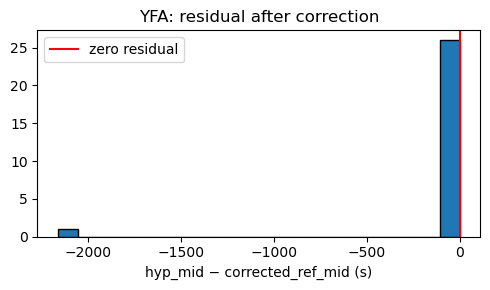


YEZ — validating corrected timing with a smaller sample:
  Searching 15 sampled ref sentences against 4915 hyp words…
    … 10/15 done, 7 anchors so far
  Found 10 anchor pairs
  Residual shift — median: 0.42 s, MAD: 0.20 s, max |residual|: 0.81 s


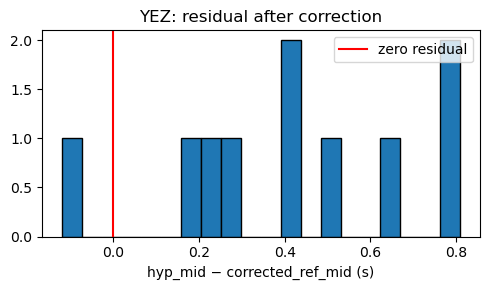

In [11]:
for pt in PATIENTS_TO_CORRECT:
    out_path   = ANILU_ROOT / pt / "words" / OUT_FILENAME
    corrected  = pd.read_csv(out_path, index_col=0)

    # Re-build sentence_id on corrected df
    sentence_id, ids = 0, []
    for word in corrected["CollapsedWord"]:
        ids.append(sentence_id)
        if any(c in {"?", "!", "."} for c in str(word)):
            sentence_id += 1
    corrected["sentence_id"] = ids

    corrected_sents = build_ref_sentences(corrected)
    print(f"\n{pt} — validating corrected timing with a smaller sample:")
    val_anchors = find_timing_anchors(
        corrected_sents, pt_hyps[pt],
        wer_thresh=0.70, sample_every=20,
    )

    if len(val_anchors) > 0:
        residuals = val_anchors["hyp_mid"] - val_anchors["ref_mid"]
        print(f"  Residual shift — median: {residuals.median():.2f} s, "
              f"MAD: {(residuals - residuals.median()).abs().median():.2f} s, "
              f"max |residual|: {residuals.abs().max():.2f} s")

        fig, ax = plt.subplots(figsize=(5, 3))
        ax.hist(residuals, bins=20, edgecolor="k")
        ax.axvline(0, color="r", lw=1.5, label="zero residual")
        ax.set_xlabel("hyp_mid − corrected_ref_mid (s)")
        ax.set_title(f"{pt}: residual after correction")
        ax.legend()
        plt.tight_layout()
        plt.show()